Esse estudo tem como objetivo fazer uma analise de Churn, para entender onde estão os gargalos para a não retenção de clientes e possiveis planos de ação para reconquistar, fidelizar ou prospectar novos clientes.

Algumas perguntas como exemplo a serem respondidas:
- Quais comportamentos e características aumentam significativamente a probabilidade de churn?    
- É possível identificar sinais comportamentais precoces de churn com antecedência suficiente para ações de retenção?   
- Qual modelo melhor separa clientes de alto e baixo risco de churn com equilíbrio entre precisão e capacidade operacional?   
- Como priorizar clientes por risco de churn e valor financeiro?  
- Qual métrica melhor representa a capacidade do modelo em identificar churn acionável sem gerar excesso de falso positivo?  
- Como traduzir previsões de churn em impacto financeiro, priorização operacional e ações de retenção?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [2]:
df = pd.read_csv(r"data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


como possuimos 7043 registros, temos que nenhuma coluna possui registros nulos. Porém o TotalCharges está como object(string) e é uma coluna que deveria ser do tipo int

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [79]:
features_num = ['tenure', 'TotalCharges','MonthlyCharges']
features_cat = ['gender','SeniorCitizen','Partner','Dependents',
                'PhoneService','MultipleLines','InternetService','OnlineSecurity',
                'OnlineBackup','DeviceProtection', 'TechSupport','StreamingTV', 
                'StreamingMovies', 'Contract', 'PaperlessBilling','PaymentMethod']

# Desbalanceamento de classes

In [20]:
desbalanceamento = df["Churn"].value_counts(normalize=True)*100
print(desbalanceamento.round(1))

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


O dataset está levemente desbalanceado, ou seja, cerca de 26.5% dos clientes dão Churn. Dessa forma, é preferivel evitar observar apenas a acuracia para avaliar o modelo.

# Analise de variaveis numéricas

Para as variaveis númericas, vamos verificar algumas hipoteses para ver se elas estão diretamente ligadas ao Churn da empresa.  
Algumas hipoteses a serem verificadas:  
- Clientes que com mais tempo de relacionamento possui maior ou menor propenção a churn?
- Como está a distribuição dos dados?
- Clientes que pagam mais se mantem fieis a empresa?

In [21]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_num
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


Calculo do coeficiente de variação para verificar se há muita disperção entre os dados

In [24]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].quantile(0.5))


In [6]:
tenure_cv = (df['tenure'].std()/df['tenure'].mean()) * 100
print(tenure_cv)

75.86842617906603


In [7]:
monthlyCarges_cv = (df['MonthlyCharges'].std()/df['MonthlyCharges'].mean()) * 100
print(monthlyCarges_cv)

46.46272503762195


aqui temos uma população de 7043 clientes.  

tenure o número de meses que o cliente possui relacionamento com a empresa  
   - Temos uma média de 32.37, mediana de 29 e desv. padrão de 24.55.  

SenioCitizen é se é ou não idoso  

MonthlyCartges é o valor cobrado mensalmente 
   - Temos uma média de 64.76, mediana de 70.35 e desv. padrão de 30.09 

   
Tanto tenure quanto MonthlyCharges possuem um coeficiente de variação alto, sendo de 76% e 46%, respectivamente, ou seja, os dados não são homogeneos. 

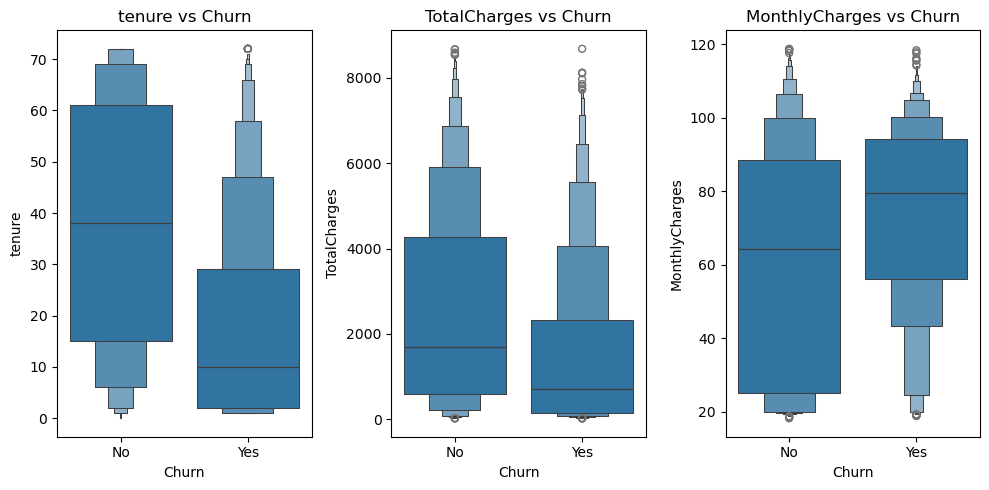

In [38]:
fig,axes = (plt.subplots(1,3,figsize=(10,5)))
axes = axes.flatten()
for i ,col in enumerate(features_num):
    sns.boxenplot( df, x= 'Churn', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

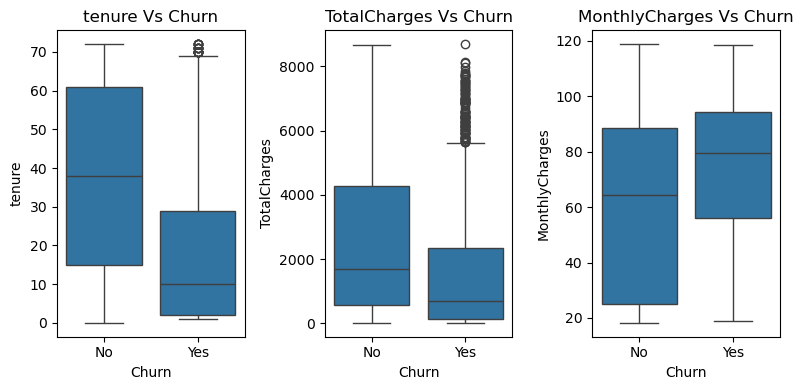

In [13]:
fig,axes =(plt.subplots(1,3,figsize=(8,4)))
axes = axes.flatten()
for i,col in enumerate(features_num):
    
    sns.boxplot(df, x='Churn', y=col, ax=axes[i])
    axes[i].set_title(f'{col} Vs Churn')
plt.tight_layout()
plt.show()


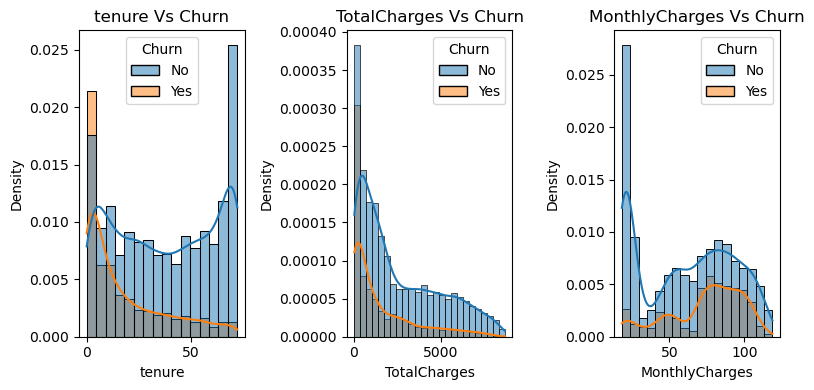

In [14]:
fig,axes =(plt.subplots(1,3,figsize=(8,4)))
axes = axes.flatten()
for i,col in enumerate(features_num):
    sns.histplot(df,
             x=col,
             hue='Churn',
             kde = True,
             stat='density',
             ax=axes[i])
    axes[i].set_title(f'{col} Vs Churn')
plt.tight_layout()
plt.show()


In [12]:
for num in features_num:
    churn_s = df[df['Churn']=='Yes'][num]
    churn_n = df[df['Churn']=='No'][num]

    stat,p = mannwhitneyu(
        churn_s,
        churn_n
    )
    print(f'{num}: {p}')

tenure: 2.419635517951866e-208
TotalCharges: 1.8396234229657706e-84
MonthlyCharges: 3.311627651988585e-54


Ao aplicarmos o teste U de Mann-Whitney, temos também que os valores são muito menores do que 0.05, ou seja, as distribuições do Churn pelas variaveis numéricas são bem definidas, o que mostra que elas podem ser evidencias de que essas variaveis interferem diretamente no Churn

In [45]:
for i in features_num:
    mediana = df.groupby('Churn')[i].median()
    print(f'\n---mediana de {i} pelo Churn: ')
    print(f'{mediana}')


---mediana de tenure pelo Churn: 
Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

---mediana de TotalCharges pelo Churn: 
Churn
No     1679.525
Yes     703.550
Name: TotalCharges, dtype: float64

---mediana de MonthlyCharges pelo Churn: 
Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64


Observando os gráficos boxplot, vemos que há uma certa dispersão para os extremos, o que pode nos responder sobre os valores do cv estarem altos 
Sendo assim a melhor metrica a ser utilziada é a mediana  

Além disso, verifiquei também que, clientes com baixo relacionamento (mediana de 10) e alto valor cobrado mensal (mediana de 80), a possibilidade de Churn é maior.   
A partir do gráfico de TotalCharges, convertendo para numérico, verifiquei que possuiam algumas linhas vazias, sendo preenchidas com o valor da mediana dessa coluna  



Text(0.5, 1.0, 'Correlação entre variaveis numéricas')

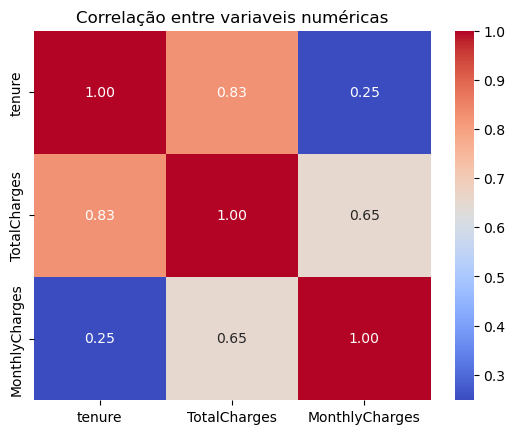

In [46]:
corr = df[features_num].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlação entre variaveis numéricas')

Verificando a correlação entre essas variaveis, o tempo de relacionamento (tenure) está fortemente correlacionado com o Total Charges, podendo inferir que as duas variaveis são forte candidatas ao Churn do cliente, além das variaveis de Montly Charges e Total Charges possuirem boa correlação, pois são variaveis dependentes.

# Analise de variaveis categóricas

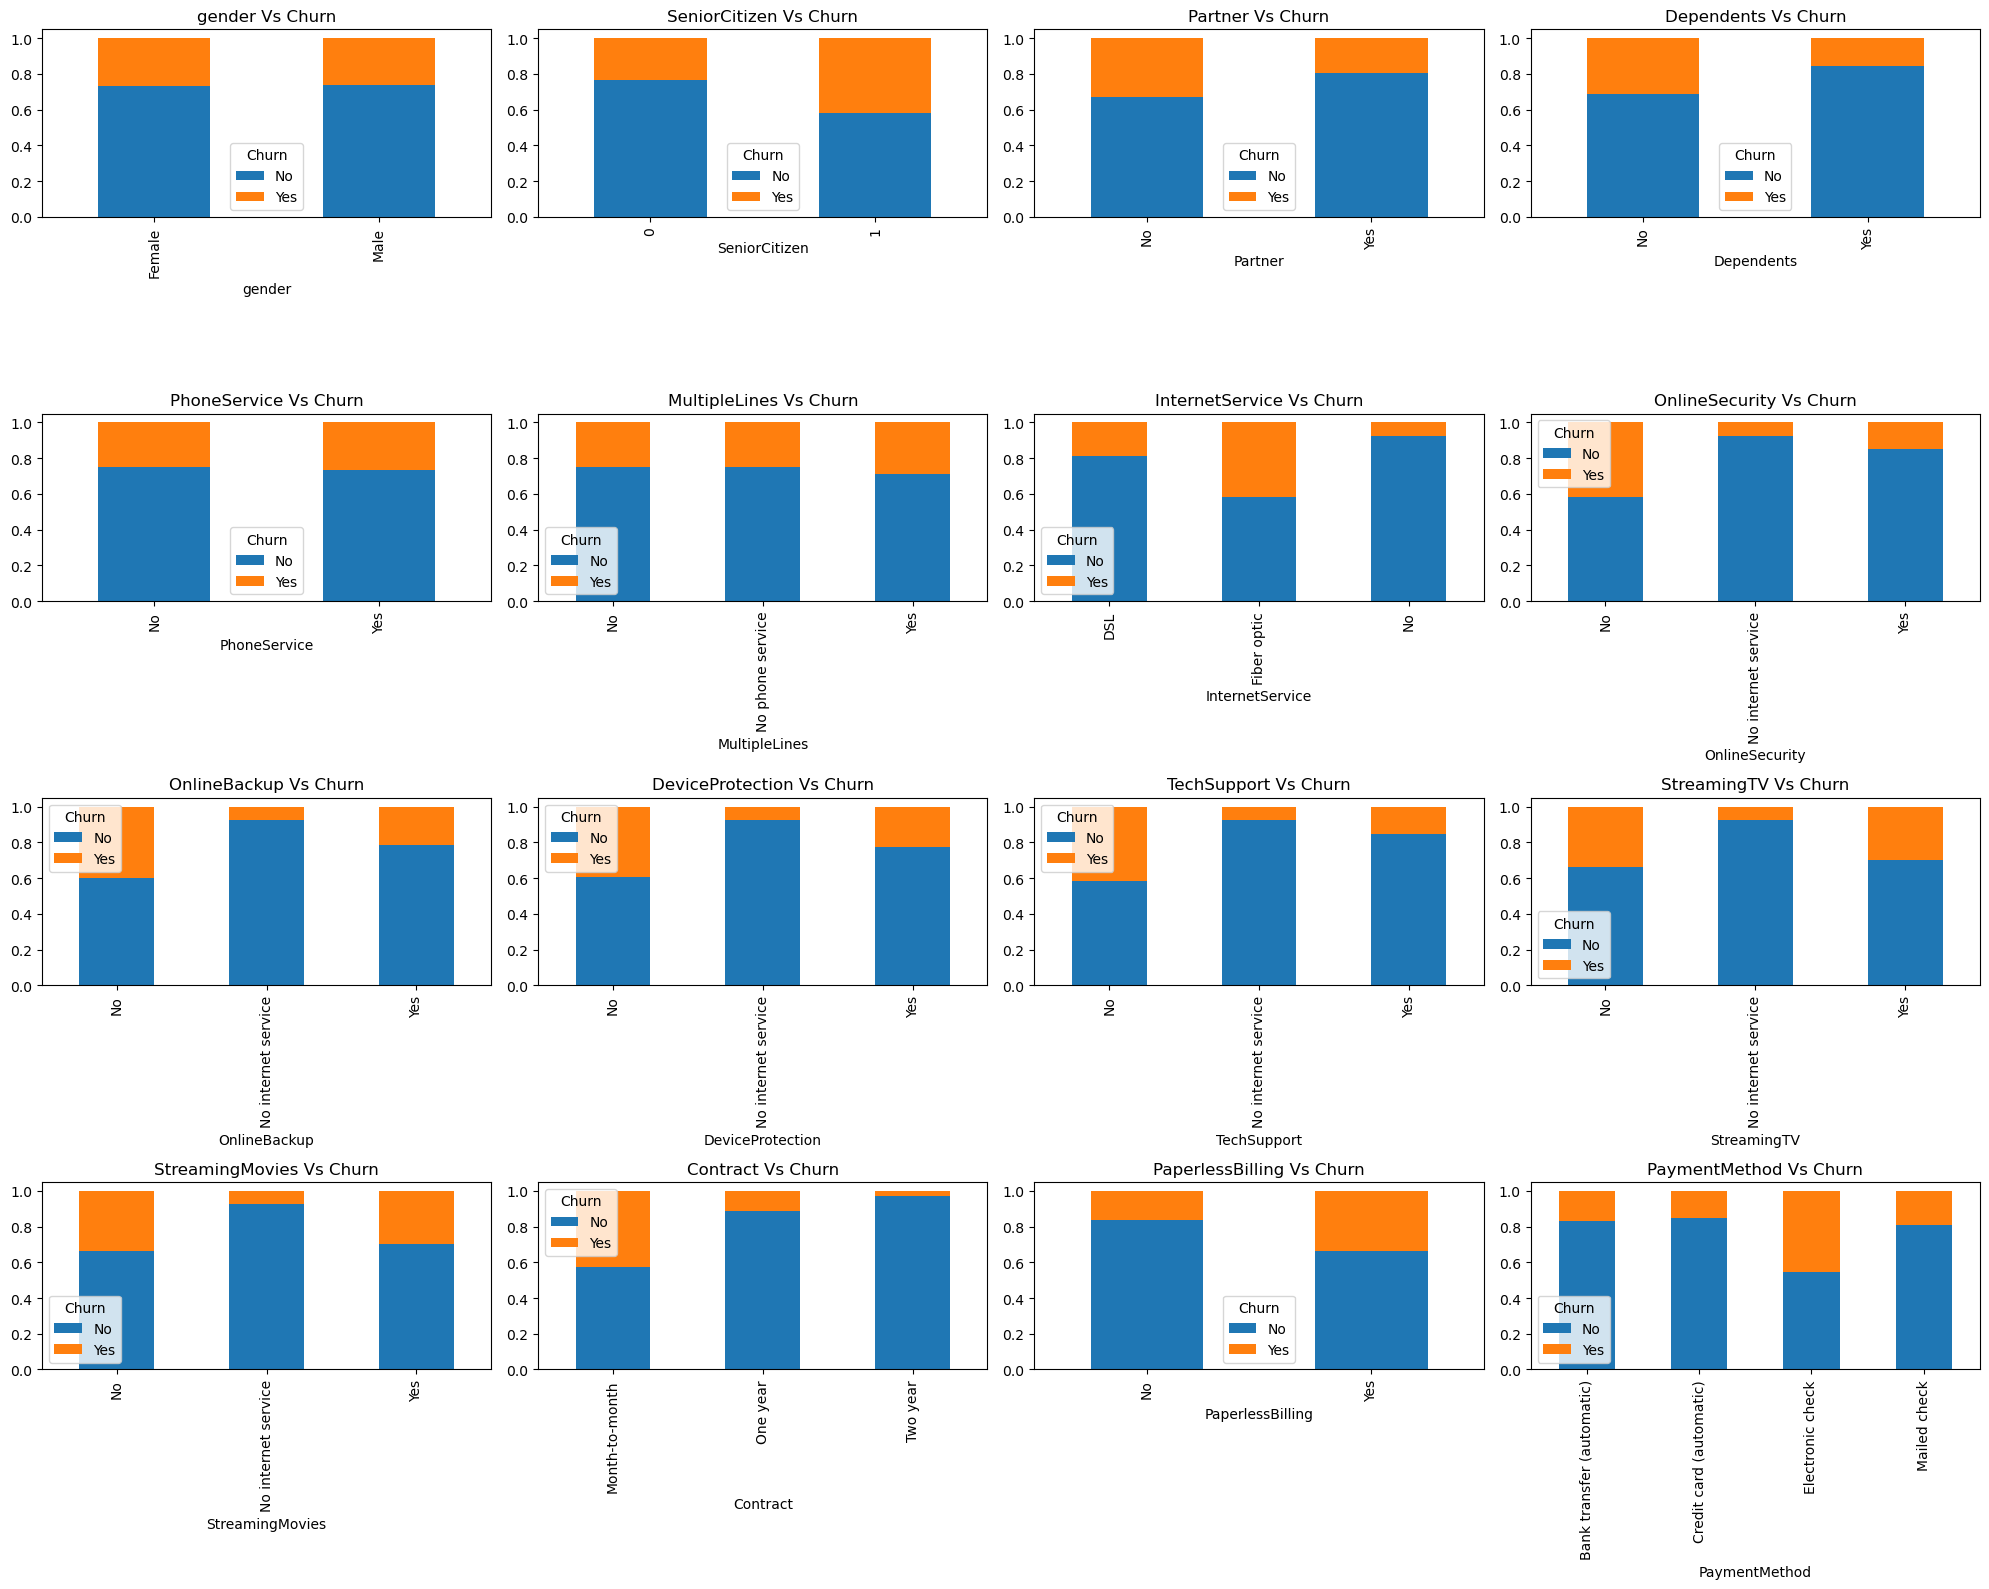

In [15]:
fig, axes = plt.subplots(4, 4, figsize = (20, 16))
axes = axes.flatten()

for i,cat in enumerate(features_cat):
    pd.crosstab(
        df[cat],
        df['Churn'],
        normalize='index'
    ).plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'{cat} Vs Churn')
plt.tight_layout()
plt.show()

In [16]:
from scipy.stats import chi2_contingency

for cat in features_cat:
    tabela = pd.crosstab(
        df[cat],
        df['Churn']
    )
    chi2, p, dof, expected= chi2_contingency(tabela)
    print(f'{cat}: {p}')

gender: 0.48657873605618596
SeniorCitizen: 1.510066805092378e-36
Partner: 2.1399113440759935e-36
Dependents: 4.9249216612154196e-43
PhoneService: 0.3387825358066928
MultipleLines: 0.0034643829548773003
InternetService: 9.571788222840544e-160
OnlineSecurity: 2.661149635176552e-185
OnlineBackup: 2.0797592160864276e-131
DeviceProtection: 5.505219496457244e-122
TechSupport: 1.4430840279998987e-180
StreamingTV: 5.528994485739183e-82
StreamingMovies: 2.667756755723681e-82
Contract: 5.863038300673391e-258
PaperlessBilling: 4.073354668665985e-58
PaymentMethod: 3.6823546520097993e-140


In [17]:
df['Churn_num'] = df['Churn'].map(
    {
        "Yes":1,
        "No": 0
    }
)

for col in features_cat:
    
    proportion = df.groupby(col)['Churn_num'].mean()*100
    print(f'\n--- Churn % por {col}')
    display(proportion.round(1))
    #print(f'{col}: {proportion}')


--- Churn % por gender


gender
Female    26.9
Male      26.2
Name: Churn_num, dtype: float64


--- Churn % por SeniorCitizen


SeniorCitizen
0    23.6
1    41.7
Name: Churn_num, dtype: float64


--- Churn % por Partner


Partner
No     33.0
Yes    19.7
Name: Churn_num, dtype: float64


--- Churn % por Dependents


Dependents
No     31.3
Yes    15.5
Name: Churn_num, dtype: float64


--- Churn % por PhoneService


PhoneService
No     24.9
Yes    26.7
Name: Churn_num, dtype: float64


--- Churn % por MultipleLines


MultipleLines
No                  25.0
No phone service    24.9
Yes                 28.6
Name: Churn_num, dtype: float64


--- Churn % por InternetService


InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn_num, dtype: float64


--- Churn % por OnlineSecurity


OnlineSecurity
No                     41.8
No internet service     7.4
Yes                    14.6
Name: Churn_num, dtype: float64


--- Churn % por OnlineBackup


OnlineBackup
No                     39.9
No internet service     7.4
Yes                    21.5
Name: Churn_num, dtype: float64


--- Churn % por DeviceProtection


DeviceProtection
No                     39.1
No internet service     7.4
Yes                    22.5
Name: Churn_num, dtype: float64


--- Churn % por TechSupport


TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2
Name: Churn_num, dtype: float64


--- Churn % por StreamingTV


StreamingTV
No                     33.5
No internet service     7.4
Yes                    30.1
Name: Churn_num, dtype: float64


--- Churn % por StreamingMovies


StreamingMovies
No                     33.7
No internet service     7.4
Yes                    29.9
Name: Churn_num, dtype: float64


--- Churn % por Contract


Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn_num, dtype: float64


--- Churn % por PaperlessBilling


PaperlessBilling
No     16.3
Yes    33.6
Name: Churn_num, dtype: float64


--- Churn % por PaymentMethod


PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: Churn_num, dtype: float64

Para as variaveis categóricas, notamos que o Churn é influenciado por alguma delas
Alguns exemplos:
SeniorCitize - Apesar de ser uma variavel numérica, pode ser entender como categórica por ser no formato binario, dessa forma mostra-se que clientes idosos tendem a darem Churn com mais facilidade, com proporção de cerca de 60/40
Partner e Dependents - A proporção mostra que quem não possui parceiro ou dependentem tem levemente a chance de darem churn também, cerca de 25 a 30%
InternetServices e serviços diversos  - Quem contratou fibra ótica também tem maior propenção ao Churn, com proporção de cerca de 40%, assim como quem não contrata qualquer tipo de pós venda do serviço (seguro, suporte tech, proteção de dispositivos e backup online )
Contract - Contratos mais curtos (month to month) tendem também a terem mais propenção ao Churn
Pagamento - Contas que não utilizam papel (paperless bills) possuem maior chance de Churn, além de cheques eletronicos

Para o restante das variaveis, o churn permanece de modo equilibrando entre as opções, podendo variar um pouco, mas não o suficiente para mostrar como uma evidencia de possivel Churn.

De acordo com o teste do qui quadrado, que faz a associação das variaveis categoricas, mostra que a leitura do grafico está aderente ao teste, pois as categorias que foi citado acima possuem associação direta com o Churn, visto que o valor de p é proximo de 0 (< 0.05)  
Também é possivel ver a proporção em % de Churn de cada categoria

# Conclusões finais

Clientes com maior risco de Churn:
- Possuem menor tempo de relacionamento e valor de pagamento maior;
- Clientes com contratos curtos (mensais) sao mais propensos a darem Churn
- Clientes que não contratam serviços adicionais também são mais propensos

Principais features para testes de modelos: tenure, MontlyCharges, TotalCharges (todas numericas), Contract, variaveis de serviços de pós vendas e adicionais, Variaveis de tipo de pagamento

Proximos passos:
- Verificar qual melhor metodo para metrificar: F1 score ou ROC-AUC 
- Testar as metricas em diferentes modelos (regressão, decision tree,randomforest, XGBoost)

# Avaliação de Modelos

Quais melhores modelos para testar as metricas
- Metricas a serem validadas:
    - F1 Score
    - ROC-AUC
- Modelos a serem testados:
    - Regressão
    - Decision Tree
    - randomforest
    - XGBoost

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,recall_score, precision_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay


In [80]:
features_full = features_cat + features_num
print(features_full)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure', 'TotalCharges', 'MonthlyCharges']


In [101]:
df['Churn'] = df['Churn'].map(
    {
        'No':0,
        'Yes':1
    })

X = df[features_full]
y = df['Churn']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state=42,
    stratify=y
)


In [102]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'),features_cat)
    ]
)


In [132]:
pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', LogisticRegression(class_weight='balanced',random_state=42, max_iter=1000))
])
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [133]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

Accuracy

In [134]:
print('Accuracy: ',accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

Accuracy:  0.7374024130589071
Recall:  0.7834224598930482
Precision:  0.5034364261168385
F1-Score:  0.6129707112970711
ROC-AUC:  0.8414063912785139


In [130]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



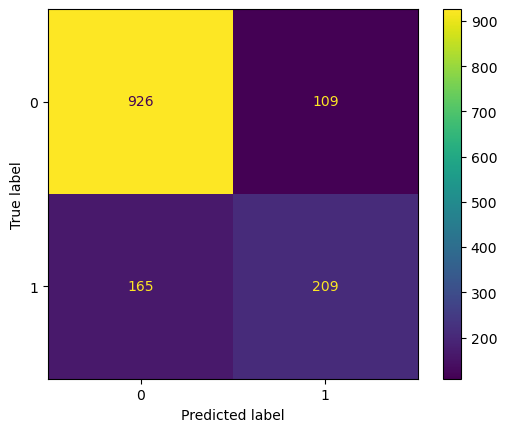

In [131]:
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))